In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

np.random.seed(42)

In [2]:
df = pd.read_csv("housing.csv")

target_column_name = "median_house_value"

feature_column_names = [col for col in df.columns if col != target_column_name]

X_full = df[feature_column_names]
y_full = df[target_column_name]

print("X shape:", X_full.shape)
print("y shape:", y_full.shape)

X shape: (20640, 9)
y shape: (20640,)


Hantera saknade värden

In [12]:
display(df.head())

print("Saknade värden per kolumn")
print(df.isna().sum())

display(X_full.describe().T)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Saknade värden per kolumn
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16512, 9)
Test shape: (4128, 9)


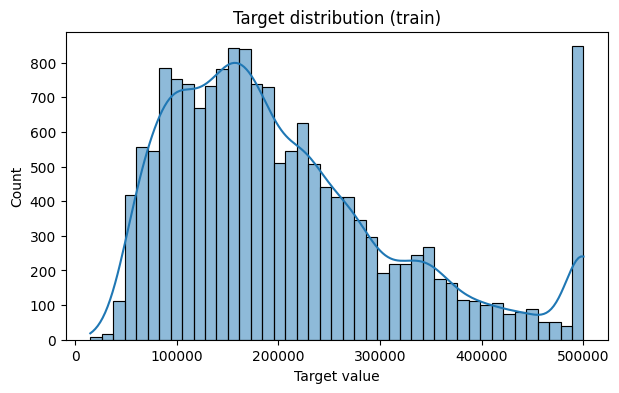

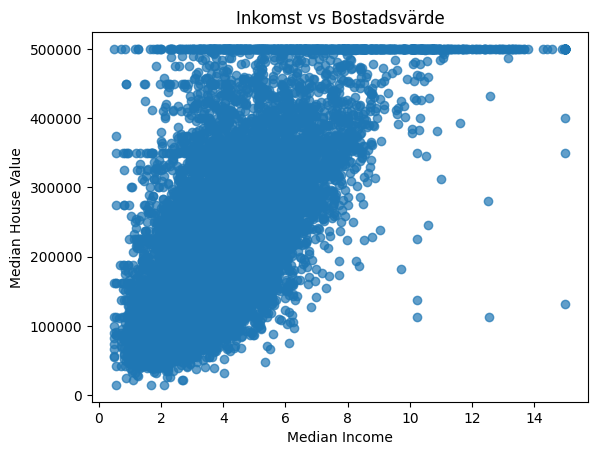

In [34]:
train_df_for_eda = X_train.copy()
train_df_for_eda[target_column_name] = y_train

plt.figure(figsize=(7,4))
sns.histplot(y_train, kde=True)
plt.title("Target distribution (train)")
plt.xlabel("Target value")
plt.show()

plt.figure()
plt.scatter(X_train["median_income"], y_train, alpha=0.7)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Inkomst vs Bostadsvärde")
plt.show()
